**Simple deep neural network withh 10 layers and vanishing gradient**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
def sigmoid(x):
  return 1/ (1 + np.exp(-x))

In [ ]:
def sigmoid_derivative(x):
  s = sigmoid(x)
  return s * (1 - s)

In [ ]:
n_layers = 10
input_size = 1
hidden_size = 1
output_size = 1

weights = []
biases = []

learning_rate = 0.1
epochs = 100

In [ ]:
X = np.array([[1], [2], [3], [4]], dtype=float)
y = np.array([[2], [4], [6], [8]], dtype=float)

In [ ]:
total_layers = n_layers + 1

for i in range (total_layers):

  if(i == 0):
    w = np.random.randn(input_size, hidden_size)
    b = np.random.randn(1, hidden_size)

    weights.append(w)
    biases.append(b)

  elif i == total_layers - 1 :
    w = np.random.randn(hidden_size, output_size)
    b = np.random.randn(1, output_size)

    weights.append(w)
    biases.append(b)

  else:
    w = np.random.randn(hidden_size, hidden_size)
    b = np.random.randn(1, hidden_size)

    weights.append(w)
    biases.append(b)



In [ ]:
losses = []
gradient_history = [[] for _ in range(len(weights))]


for epoch in range(epochs):
  activations =[X]
  z_values = []

  for i in range (len(weights)):
    z = np.dot(activations[i], weights[i]) + biases[i]
    z_values.append(z)
    activations.append(sigmoid(z))

  output = activations[-1]

  loss = np.mean((y - output) ** 2)
  losses.append(loss)

  error = (y - output) * sigmoid_derivative(output)

  for i in reversed(range(len(weights))):
    dW = np.dot(activations[i].T, error)

    grad_norm = np.linalg.norm(dW)
    gradient_history[i].append(grad_norm)

    dB = np.sum(error, axis=0, keepdims= True)

    weights[i] += learning_rate * dW
    biases[i] += learning_rate * dB

    if i != 0:
      error = np.dot(error, weights[i].T) * sigmoid_derivative(activations[i])



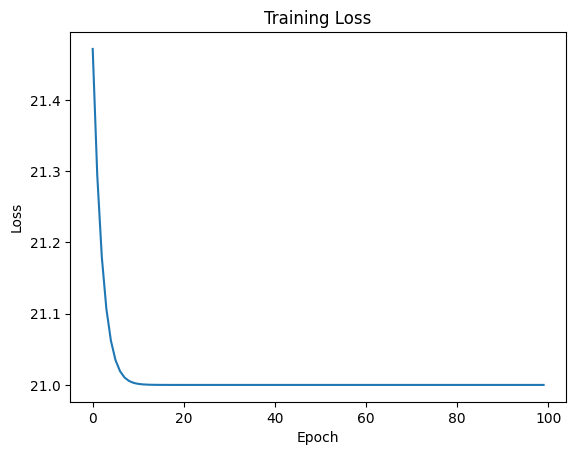

In [ ]:
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.show()

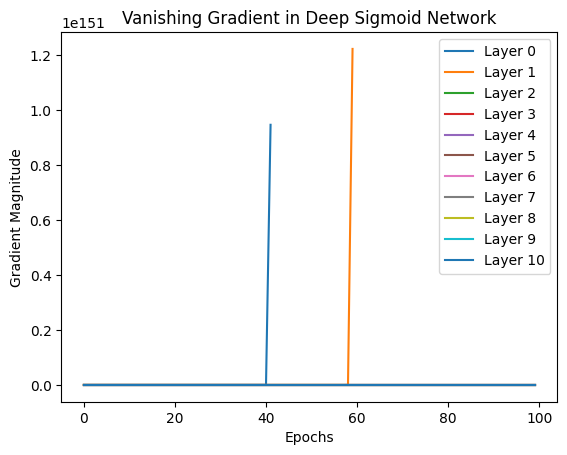

In [ ]:
plt.figure()

for i in range(len(gradient_history)):
    plt.plot(gradient_history[i], label=f"Layer {i}")

plt.xlabel("Epochs")
plt.ylabel("Gradient Magnitude")
plt.title("Vanishing Gradient in Deep Sigmoid Network")
plt.legend()
plt.show()

**Symmetry problem**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

In [ ]:
n_layers = 10
input_size = 1
hidden_size = 1
output_size = 1

learning_rate = 0.1
epochs = 100

In [ ]:
X = np.array([[1], [2], [3], [4]], dtype=float)
y = np.array([[2], [4], [6], [8]], dtype=float)

In [ ]:
weights = []
biases = []

total_layers = n_layers + 1

for i in range(total_layers):

    if i == 0:
        w = np.ones((input_size, hidden_size))
        b = np.zeros((1, hidden_size))

    elif i == total_layers - 1:
        w = np.ones((hidden_size, output_size))
        b = np.zeros((1, output_size))

    else:
        w = np.ones((hidden_size, hidden_size))
        b = np.zeros((1, hidden_size))

    weights.append(w)
    biases.append(b)


In [ ]:
losses = []

for epoch in range(epochs):

    activations = [X]

    for i in range(len(weights)):
        z = np.dot(activations[i], weights[i]) + biases[i]
        a = sigmoid(z)
        activations.append(a)

    output = activations[-1]

    loss = np.mean((y - output) ** 2)
    losses.append(loss)

    error = (y - output) * sigmoid_derivative(output)

    for i in reversed(range(len(weights))):
        dW = np.dot(activations[i].T, error)
        dB = np.sum(error, axis=0, keepdims=True)

        weights[i] += learning_rate * dW
        biases[i] += learning_rate * dB

        if i != 0:
            error = np.dot(error, weights[i].T) * sigmoid_derivative(activations[i])


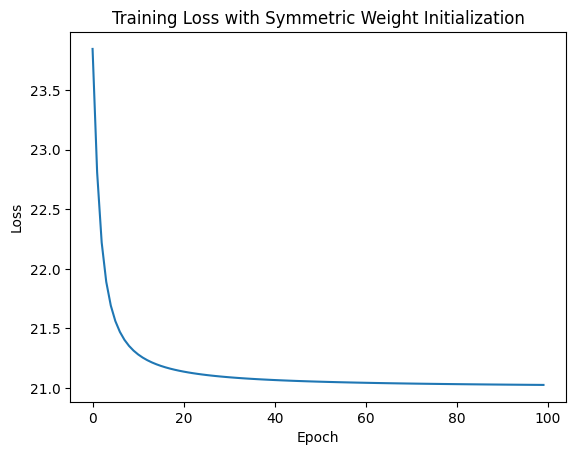

In [ ]:
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss with Symmetric Weight Initialization")
plt.show()

**Task 4 : Implementation of the xavier formula**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
def sigmoid(x):
  return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
  return x * (1 - x)

In [ ]:
def xavier_init(in_size, out_size):
  std = np.sqrt(2 / (in_size + out_size))
  return np.random.randn(in_size, out_size) * std;

In [ ]:
n_layers = 10
input_size = 1
output_size = 1
hidden_size = 1

learning_rate = 0.1
epochs = 100

In [ ]:
X = np.array([[1], [2], [3], [4]], dtype=float)
y = np.array([[2], [4], [6], [8]], dtype=float)

In [ ]:
weights = []
biases = []

total_layers = n_layers + 1

for i in range(total_layers):

    if i == 0:
        w = xavier_init(input_size, hidden_size)
        b = np.zeros((1, hidden_size))

    elif i == total_layers - 1:
        w = xavier_init(hidden_size, output_size)
        b = np.zeros((1, output_size))

    else:
        w = xavier_init(hidden_size, hidden_size)
        b = np.zeros((1, hidden_size))

    weights.append(w)
    biases.append(b)

In [ ]:
losses = []
gradient_history = [[] for _ in range(len(weights))]

for epoch in range(epochs):

    activations = [X]


    for i in range(len(weights)):
        z = np.dot(activations[i], weights[i]) + biases[i]
        a = sigmoid(z)
        activations.append(a)

    output = activations[-1]

    loss = np.mean((y - output) ** 2)
    losses.append(loss)

    error = (y - output) * sigmoid_derivative(output)

    #backpropagation
    for i in reversed(range(len(weights))):
        dW = np.dot(activations[i].T, error)

        grad_norm = np.linalg.norm(dW)
        gradient_history[i].append(grad_norm)

        dB = np.sum(error, axis=0, keepdims=True)

        weights[i] += learning_rate * dW
        biases[i] += learning_rate * dB

        if i != 0:
            error = np.dot(error, weights[i].T) * sigmoid_derivative(activations[i])


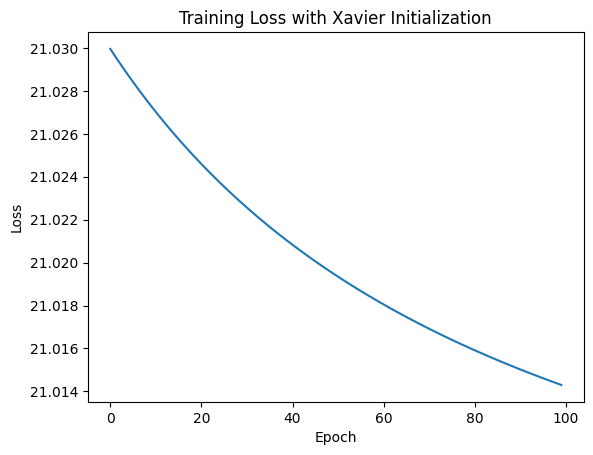

In [ ]:
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss with Xavier Initialization")
plt.show()

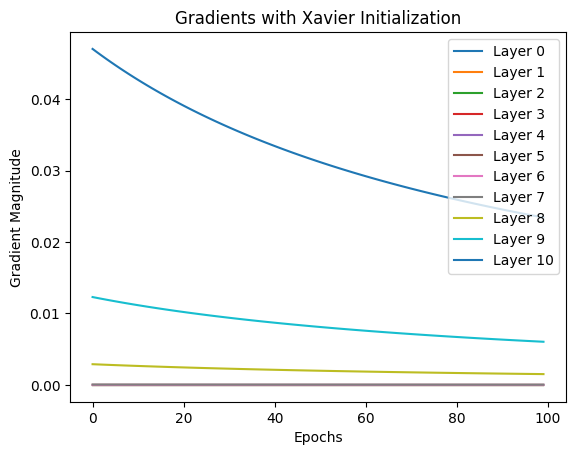

In [ ]:
plt.figure()
for i in range(len(gradient_history)):
    plt.plot(gradient_history[i], label=f"Layer {i}")

plt.xlabel("Epochs")
plt.ylabel("Gradient Magnitude")
plt.title("Gradients with Xavier Initialization")
plt.legend()
plt.show()